# [IAPR][iapr]: Final project - Chocolate Recognition


**Moodle group ID:** *28*  
**Kaggle challenge:** *Deep learning* (either `Classic` or `Deep learning`)  
**Kaggle team name (exact):** "*xx*"  

**Author 1 (SCIPER):** Luc Harrison (315788)  
**Author 2 (SCIPER):** Elias Da Ros (315141)
**Author 3 (SCIPER):** Rim El Qabli (340997)  

**Due date:** 21.05.2025 (11:59 pm)


## Key Submission Guidelines:
- **Before submitting your notebook, <span style="color:red;">rerun</span> it from scratch!** Go to: `Kernel` > `Restart & Run All`
- **Only groups of three will be accepted**, except in exceptional circumstances.


[iapr]: https://github.com/LTS5/iapr2025

---

# Project Goal and Strategy

The goal of this project is to detect and count the number of different types of chocolates in each image, leveraging both the images and their corresponding per-class chocolate counts. Our initial approach involved using classical computer vision techniques for segmentation and recognition, followed by testing deep learning models to do the classification and counting at the same time. However, these methods did not yield satisfactory results, prompting us to explore alternative strategies.

Initially, we attempted to use a U-Net architecture for segmentation, followed by a CNN for classification. While this approach showed some promise, it struggled with accurately segmenting chocolates in cluttered (or with a strong background) or low-contrast images. Additionally, the classification model faced challenges in distinguishing between visually similar chocolate types, leading to a low F1 score on unseen data (especially when there was a background).

After testing multiple methods and analyzing their limitations, we opted for a more robust and scalable approach using a Faster R-CNN model. This model integrates object detection and classification into a single pipeline, allowing us to directly detect and classify chocolates in images (which enables us to count them). Below, we summarize the key components of our final pipeline:

1. **Dataset Preparation**:
   - The dataset was annotated manually in COCO format, with bounding boxes (representing regions of interests, i.e where the chocolates are located on the image) and class labels for 13 chocolate types and 1 background class. 
   - Data augmentation techniques were applied to improve model generalization (we resized the images for computational efficiency).

2. **Model Architecture**:
   - The Faster R-CNN model is composed of several key components, each playing a specific role in the detection and classification process:
     1. **Backbone (ResNet-18)**:
        - Extracts features from the input image.
        - Layers 2, 3, and 4 of ResNet-18 are used to capture low-level (edges), mid-level (shapes), and high-level (object parts) features, respectively.
        - These features are essential for identifying chocolates of varying shapes and sizes.
     2. **Feature Pyramid Network (FPN)**:
        - Combines features from different scales into a unified representation.
        - Ensures that both small and large chocolates are effectively detected by leveraging multi-scale feature maps.
        - Reduces all feature maps to 64 channels for computational efficiency.
     3. **Region Proposal Network (RPN)**:
        - Proposes candidate regions (bounding boxes) where objects might be located.
        - Uses anchors of different sizes and aspect ratios to handle chocolates of varying shapes and sizes (defined by us).
        - Filters out regions with low objectness scores to focus on likely chocolate locations.
     4. **RoI Pooling**:
        - Extracts fixed-size feature maps for each proposed region using multi-scale pooling.
        - Ensures that the subsequent classification and regression layers receive consistent input sizes, regardless of the original region dimensions.
     5. **TwoMLPHead**:
        - A lightweight two-layer fully connected head for classification and bounding box regression.
        - Predicts the class probabilities and refines the bounding box coordinates for each region.
     6. **Final Predictor**:
        - Outputs the final class labels and bounding box adjustments for the detected chocolates.
        - Applies a confidence threshold (we used 0.55) to filter out low-confidence predictions.

3. **Training**:
   - The model was trained using a combination of classification, bounding box regression, and RPN losses.
   - Cross-validation was employed to ensure robust performance across different data splits.

4. **Inference**:
   - During inference, the trained model was used to detect and classify chocolates in test images. Predictions were filtered based on a confidence threshold, and results were saved to a CSV file.

5. **Evaluation**:
   - The model's performance was evaluated using metrics such as Intersection over Union (IoU), F1-score.
   <!-- - Visualizations of ground truth and predicted bounding boxes were used to qualitatively assess the model's accuracy. -->

Overall, the Faster R-CNN model achieved a high F1 score on the unknown test set (Kaggle) of 0.86129 indicating its effectivenes and ability to generalize in classifying and counting chocolates in various images with different backgrounds and lighting conditions.

## 1. Dataset Preparation
The dataset is in COCO format, with annotations for 13 chocolate classes and 1 background class. The `ChocolateCocoDataset` class loads the dataset and applies transformations.

ChocolateCocoDataset defined. This class loads images and annotations from a COCO-format dataset, applies optional transforms, and returns images with their bounding boxes and labels.
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Number of images: 90
Classes: ['Amandina', 'Arabia', 'Comtesse', 'Creme_brulee', 'Jelly_Black', 'Jelly_Milk', 'Jelly_White', 'Noblesse', 'Noir_authentique', 'Passion_au_lait', 'Stracciatella', 'Tentation_noir', 'Triangolo']
Example item (image tensor shape, target keys):
<built-in method size of Tensor object at 0x136568810> dict_keys(['boxes', 'labels', 'image_id'])


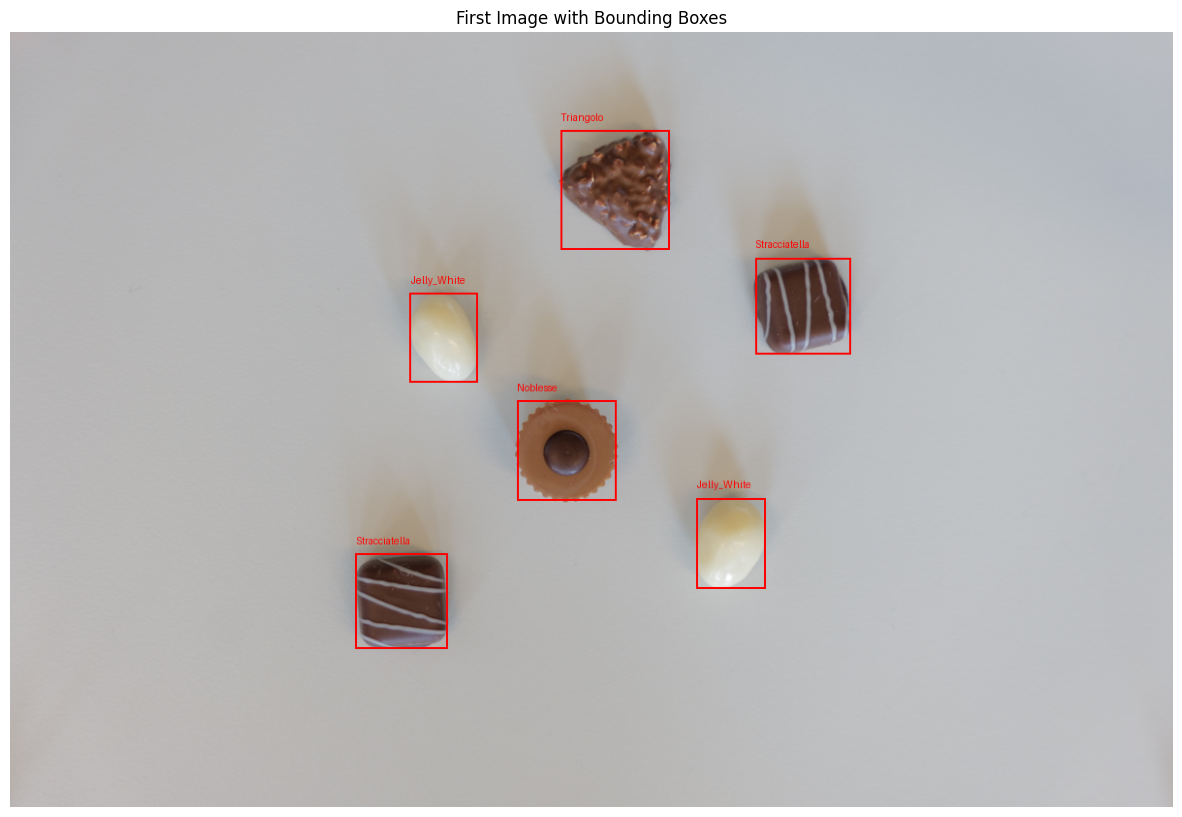

In [1]:
import torch
from pycocotools.coco import COCO
from PIL import Image, ImageDraw
from src.utils import get_transform
import os
from PIL import ImageFont
import matplotlib.pyplot as plt

class ChocolateCocoDataset(torch.utils.data.Dataset):
    def __init__(self, img_folder, coco_json, transforms=None):
        self.img_folder = img_folder
        self.coco = COCO(coco_json)
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.transforms = transforms

        # Mapping COCO category ids to classes 0 to C-1
        cats = self.coco.loadCats(self.coco.getCatIds())
        cats = sorted(cats, key=lambda x: x['id'])
        self.cat2label = {c['id']: i for i, c in enumerate(cats)}
        self.labels = [c['name'] for c in cats]

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        raw_name = self.coco.loadImgs(img_id)[0]['file_name']
        
        fp = os.path.join(self.img_folder, raw_name)
        if not os.path.exists(fp):
            base, ext = os.path.splitext(raw_name)
            alt = base + ext.upper()
            alt_fp = os.path.join(self.img_folder, alt)
            if os.path.exists(alt_fp):
                fp = alt_fp
            else:
                raise FileNotFoundError(f"Could not find image {raw_name} (or {alt}) in {self.img_folder}")
        img = Image.open(fp).convert("RGB")

        boxes = []
        labels = []
        for ann in anns:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])  # Convert to top-left and bottom-right format
            # Shifting everything into 1 to C so that 0 stays reserved for background
            labels.append(self.cat2label[ann['category_id']] + 1)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id])
        }

        if self.transforms:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.ids)

# Explain what is happening and print some info
print("ChocolateCocoDataset defined. This class loads images and annotations from a COCO-format dataset, applies optional transforms, and returns images with their bounding boxes and labels.")


dataset = ChocolateCocoDataset(
    img_folder="dataset_project_iapr2025/images",
    coco_json="dataset_project_iapr2025/train_coco_dataset.json",
    transforms=get_transform(train=False)
)

print(f"Number of images: {len(dataset)}")
print(f"Classes: {dataset.labels}")
print("Example item (image tensor shape, target keys):")
img, target = dataset[0]
print(img.size if hasattr(img, 'size') else img.shape, target.keys())

# Plot the first image with bounding boxes
# Convert the image tensor to PIL Image for visualization
img = img.permute(1, 2, 0).numpy()  # Convert from CxHxW to HxWxC
img = (img * 255).astype('uint8')  # Scale to [0, 255]
img = Image.fromarray(img)
# Draw bounding boxes
draw = ImageDraw.Draw(img)
for box, label in zip(target['boxes'], target['labels']):
    x_min, y_min, x_max, y_max = box.tolist()
    draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=2)  # Adjust rectangle drawing
    label_text = dataset.labels[label.item() - 1]  # Get the label name (adjusting for 1-based indexing)
    # Add some space above the box and increase font size
    text_y = y_min - 20 if y_min - 20 > 0 else y_min + 5  # avoid going out of image
    draw.text((x_min, text_y), label_text, fill="red")

plt.figure(figsize=(15, 15))
plt.imshow(img)
plt.axis("off")
plt.title("First Image with Bounding Boxes")
plt.show()

## The above data that was manually annotated in COCO format is what we used to train our model.

## 2. Model Definition
The model is a Faster R-CNN with a ResNet-18 backbone, Feature Pyramid Network (FPN), and a lightweight TwoMLPHead. It predicts bounding boxes and class probabilities for chocolates.

In [2]:
import torch
import torch.nn as nn
import torchvision
from torchvision.models.detection.faster_rcnn import FasterRCNN, FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import MultiScaleRoIAlign
from torchvision.ops.feature_pyramid_network import FeaturePyramidNetwork
from torchvision.models._utils import IntermediateLayerGetter

# Light Two‐layer head 
class TwoMLPHead(nn.Module):
    def __init__(self, in_channels, representation_size):
        super().__init__()
        self.fc6 = nn.Linear(in_channels, representation_size)
        self.fc7 = nn.Linear(representation_size, representation_size)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = self.relu(self.fc6(x))
        x = self.relu(self.fc7(x))
        return x

def get_model(num_classes):
    # Fresh ResNet-18, extracting layer2,3,4 → C3,C4,C5
    backbone_net = torchvision.models.resnet18(pretrained=False)
    return_layers = {'layer2':'feat2', 'layer3':'feat3', 'layer4':'feat4'}
    body = IntermediateLayerGetter(backbone_net, return_layers=return_layers)

    # Tiny FPN on those three maps, all reduced to 64 channels
    in_channels_list = [128, 256, 512]  # channels of layer2,3,4
    fpn_out_channels = 64
    fpn = FeaturePyramidNetwork(
        in_channels_list=in_channels_list,
        out_channels=fpn_out_channels
    )

    # Gluing body + FPN
    backbone = nn.Sequential(body, fpn)
    backbone.out_channels = fpn_out_channels

    # Anchor sizes 
    anchor_sizes = (
        (256, 320, 384, 448),   # P3  for small objects
        (384, 448, 512, 576),   # P4  for medium
        (512, 576, 640, 704),   # P5  for large
    )
    anchor_aspect_ratios = (
        (0.75, 1.0, 1.33),      # P3
        (0.75, 1.0, 1.33),      # P4
        (0.75, 1.0, 1.33),      # P5
    )

    anchor_generator = AnchorGenerator(
        sizes=anchor_sizes,
        aspect_ratios=anchor_aspect_ratios
    )

    # RoI pooling across the three FPN levels
    roi_pooler = MultiScaleRoIAlign(
        featmap_names=['feat2','feat3','feat4'],
        output_size=7,
        sampling_ratio=2
    )

    # Build the Faster R-CNN
    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )

    # Slim down the box head to a small TwoMLPHead (32-dim)
    pooled_h, pooled_w = model.roi_heads.box_roi_pool.output_size
    in_channels = backbone.out_channels * pooled_h * pooled_w   # 64*7*7 = 3136
    rep_size   = 180

    model.roi_heads.box_head = TwoMLPHead(in_channels, rep_size)
    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_channels=rep_size,
        num_classes=num_classes
    )

    return model

num_classes = 14  # 13 chocolates + 1 background
model = get_model(num_classes)
# Print the number of parameters in the model
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_params / 1e6:.4f}M\n")

Number of trainable parameters: 11.9956M



/opt/anaconda3/envs/iapr_project/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/iapr_project/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


### Rationale Behind Model Design Choices

The model's design choices were carefully made to balance performance and computational efficiency. The ResNet-18 backbone was selected for its lightweight architecture, making it suitable for training on limited hardware while still providing robust feature extraction. The Feature Pyramid Network (FPN) reduces all feature maps to 64 channels, ensuring computational efficiency without sacrificing multi-scale feature representation. The anchor sizes and aspect ratios were tailored to handle chocolates of varying shapes and sizes, with smaller anchors for compact objects and larger anchors for broader ones (these values were chosen by inspecting the images to get an approximation of the chocolate sizes using the training dataset). The TwoMLPHead was kept relatively small with a 32-dimensional representation size to reduce the number of parameters, making the model faster to train and less prone to overfitting (to also respect the 12M parameter limit).

### Explanation of Model Components
1. **Backbone (ResNet-18)**:
   - Extracts features from the input image.
   - Layers 2, 3, and 4 are used because they capture low-level (edges), mid-level (shapes), and high-level (object parts) features, respectively.

2. **Feature Pyramid Network (FPN)**:
   - Combines features from different scales into a unified representation.
   - Reduces all feature maps to 64 channels for computational efficiency.

3. **Region Proposal Network (RPN)**:
   - Proposes candidate regions (bounding boxes) where objects might be located.
   - Uses anchors of different sizes and aspect ratios to handle chocolates of varying shapes and sizes.

4. **RoI Pooling**:
   - Extracts fixed-size feature maps for each proposed region using multi-scale pooling.

5. **TwoMLPHead**:
   - A lightweight two-layer fully connected head for classification and bounding box regression.

6. **Final Predictor**:
   - Predicts class probabilities and bounding box adjustments.

## 3. Training
The model is trained using cross-validation and final retraining. The loss function combines classification, bounding box regression, and RPN losses.

In [3]:
# ADD THE TRAINING CODE AND DESCRIPTION BELOW IN MARKDOWN (DO NOT RUN IT JUST PUT THE FUNCTION)
### Y'a moyen de pas mettre tout le code
import os
import random
import numpy as np
import torch
import torch.backends.cudnn as cudnn
from torch.utils.data import DataLoader, Subset
from torchvision.ops import box_iou
from sklearn.model_selection import KFold

from src.dataset import ChocolateCocoDataset
from src.model import get_model
from src.utils import (
    get_transform, collate_fn,
    save_model, visualize_predictions,
    compute_counts_from_preds, image_f1
)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    cudnn.deterministic = True
    cudnn.benchmark = False

def train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=50):
    model.train()
    for i, (images, targets) in enumerate(data_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss_classifier = loss_dict['loss_classifier']
        loss_box_reg    = loss_dict['loss_box_reg']
        losses = sum(loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        if i % print_freq == 0:
            print(
                f"Epoch {epoch} [{i}/{len(data_loader)}]  "
                f"cls={loss_classifier.item():.4f}  "
                f"box={loss_box_reg.item():.4f}  "
                f"total={losses.item():.4f}"
            )
            # quick IoU check
            model.eval()
            with torch.no_grad():
                preds = model(images)
            ious = []
            for p, t in zip(preds, targets):
                if len(p["boxes"]) and len(t["boxes"]):
                    m = box_iou(p["boxes"], t["boxes"])
                    best_pred_iou, _ = m.max(dim=1)
                    ious.append(best_pred_iou.mean().item())
            avg_iou = sum(ious)/len(ious) if ious else 0.0
            print(f"    avg batch IoU: {avg_iou:.3f}")
            model.train()

def run_training(args):
    # reproducibility
    set_seed(args.seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("Using device:", device)

    base_imgs = args.train_imgs
    base_json = args.coco_json
    idx_dataset = ChocolateCocoDataset(base_imgs, base_json, transforms=None)
    labels = idx_dataset.labels

    # Cross Validation
    if args.k_folds > 0 and not args.skip_cv:
        
        kf = KFold(n_splits=args.k_folds, shuffle=True, random_state=args.seed)
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(idx_dataset), 1):
            print(f"\n=== Fold {fold}/{args.k_folds} ===")
            
            # Creating output directories for each fold
            run_dir    = os.path.join(args.output_root, f"{args.run_name}_fold{fold}")
            models_dir = os.path.join(run_dir, "models")
            vis_dir    = os.path.join(run_dir, "visuals")
            os.makedirs(models_dir, exist_ok=True)
            os.makedirs(vis_dir,    exist_ok=True)
            
            # Train and validation datasets
            train_full = ChocolateCocoDataset(
                base_imgs, base_json, transforms=get_transform(train=True)
            )
            val_full   = ChocolateCocoDataset(
                base_imgs, base_json, transforms=get_transform(train=False)
            )
            
            train_ds = Subset(train_full, train_idx)
            val_ds   = Subset(val_full,   val_idx)
            
            # Data loaders
            g = torch.Generator() 
            g.manual_seed(args.seed)
            
            train_loader = DataLoader(
                train_ds, batch_size=args.batch_size,
                shuffle=True, num_workers=args.num_workers,
                collate_fn=collate_fn,
                worker_init_fn=seed_worker,
                generator=g
            )
            val_loader = DataLoader(
                val_ds, batch_size=args.batch_size,
                shuffle=False, num_workers=args.num_workers,
                collate_fn=collate_fn,
                worker_init_fn=seed_worker,
                generator=g
            )
            
            # Model, optimizer, scheduler
            num_classes = len(labels) + 1
            model = get_model(num_classes).to(device)
            print(f"  → Params: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.6f} M")
            
            optimizer = torch.optim.SGD(model.parameters(), lr=args.lr,
                                        momentum=0.9, weight_decay=5e-4)
            
            lr_scheduler = torch.optim.lr_scheduler.StepLR(
                optimizer, step_size=args.step_size, gamma=args.gamma
            )
            
            best_val_f1, no_improve = 0.0, 0

            # Epochs loop
            for epoch in range(1, args.epochs+1):
                train_one_epoch(model, optimizer, train_loader, device, epoch)
                lr_scheduler.step()
                
                # Validation F1 score 
                model.eval()
                all_f1 = []
                for images, targets in val_loader:
                    images = [img.to(device) for img in images]
                    
                    with torch.no_grad():
                        batch_preds = model(images)
                        
                    for t, p in zip(targets, batch_preds):
                        # ground-truth counts:
                        true_counts = t["labels"].cpu().numpy()
                        y_true = np.bincount(true_counts, minlength=num_classes+1)[1:]
                        # predicted counts:
                        y_pred = compute_counts_from_preds(p, args.conf_thresh_score, num_classes)
                        all_f1.append(image_f1(y_true, y_pred))
                        
                avg_val_f1 = float(np.mean(all_f1))
                print(f" → Val F1: {avg_val_f1:.4f}")

                # Early stopping based on F1 score
                if avg_val_f1 > best_val_f1:
                    best_val_f1 = avg_val_f1
                    no_improve = 0
                    save_model(model, os.path.join(models_dir, "best.pth"))
                else:
                    no_improve += 1
                    
                if no_improve >= args.patience:
                    print(f"No F1 improvement for {args.patience} epochs, stopping.")
                    break
                    
                model.train()
                
                # Save and visualize
                visualize_predictions(
                    model, 
                    val_ds.dataset, 
                    labels, device,
                    epoch, vis_dir,
                    n_samples=args.visual_samples,
                    conf_thresh=args.conf_thresh_vis
                )
                
            save_model(model, os.path.join(models_dir, "last.pth"))

        print("All folds complete.\nTraining complete.")
        
    else:
        print("Skipping cross-validation; proceeding straight to final retrain…")

    # ──────────────────────────────────────────────────────────────────────────
    # Final retrain on ALL data
    print("\n▶︎ Retraining on full dataset for final model…")
    
    final_dir = os.path.join(args.output_root, f"{args.run_name}_final")
    os.makedirs(final_dir, exist_ok=True)
    os.makedirs(os.path.join(final_dir, "visuals"), exist_ok=True)

    # Full dataset and loader
    full_ds = ChocolateCocoDataset(
        base_imgs, base_json, transforms=get_transform(train=True)
    )
    
    g_full = torch.Generator(); g_full.manual_seed(args.seed)

    full_loader = DataLoader(full_ds, batch_size=args.batch_size,
                             shuffle=True, num_workers=args.num_workers,
                             collate_fn=collate_fn,
                             worker_init_fn=seed_worker,
                             generator=g_full)

    # Validation held-out dataset and loader
    full_val_ds = ChocolateCocoDataset(
        base_imgs, base_json, transforms=get_transform(train=False)
    )
    
    val_loader_full = DataLoader(full_val_ds, batch_size=args.batch_size,
                                 shuffle=False, num_workers=args.num_workers,
                                 collate_fn=collate_fn,
                                 worker_init_fn=seed_worker,
                                 generator=g_full)

    # Building a fresh model and optimizer/scheduler
    num_classes = len(labels) + 1
    final_model = get_model(num_classes).to(device)
    final_optimizer = torch.optim.SGD(
        final_model.parameters(),
        lr=args.lr, 
        momentum=0.9, 
        weight_decay=5e-4
    )
    final_scheduler = torch.optim.lr_scheduler.StepLR(
        final_optimizer, step_size=args.step_size, gamma=args.gamma
    )
    
    best_full_f1 = 0.0
    no_imp_full  = 0

    # Train for final_epochs
    for epoch in range(1, args.final_epochs+1):
        train_one_epoch(
            final_model, 
            final_optimizer, 
            full_loader, 
            device, 
            epoch
        )
        final_scheduler.step()

        # Computing F1 on full_val_ds
        final_model.eval()
        all_f1 = []
        for images, targets in val_loader_full:
            images = [img.to(device) for img in images]
            with torch.no_grad():
                preds = final_model(images)
            for t, p in zip(targets, preds):
                y_true = np.bincount(t["labels"].cpu().numpy(),
                                    minlength=num_classes+1)[1:]
                y_pred = compute_counts_from_preds(p, args.conf_thresh_score, num_classes)
                all_f1.append(image_f1(y_true, y_pred))
                
        avg_full_f1 = float(np.mean(all_f1))
        print(f" → Full‐data Val F1: {avg_full_f1:.4f}")

        # Early stop / saving best_full.pth
        if avg_full_f1 > best_full_f1:
            best_full_f1, no_imp_full = avg_full_f1, 0
            save_model(final_model, os.path.join(final_dir, "best_full.pth"))
            
        else:
            no_imp_full += 1
            
        if no_imp_full >= args.patience:
            print(f"No full‐data F1 improvement for {args.patience} epochs, stopping final retrain.")
            break
            
        visualize_predictions(
            final_model, 
            full_val_ds, 
            labels, 
            device,
            epoch, os.path.join(final_dir, "visuals"),
            n_samples=args.visual_samples,
            conf_thresh=args.conf_thresh_vis
        )
        final_model.train()

    # Saving last model
    save_model(final_model, os.path.join(final_dir, "last.pth"))


The training process involves two key steps:
- cross-validation (if enabled) to ensure robust performance across different data splits by testing on data that the model has not seen during training.
- final retraining on the entire dataset to maximize the model's ability to generalize to unseen data.

This two-step approach guarantees that the model is robust and should perform well on unseen data (i.e the testing data). 

One important aspect of this process is the use of SGD (Stochastic Gradient Descent) as the optimizer. We benefit from the use of the`momentum` parameter, which helps accelerate the convergence of the model during training and avoid poor local minima as well as oscillations. The `weight_decay` parameter adds a penalty for large weights, which encourages the model to learn simpler patterns in the data, thus avoiding overfitting during the training process and leading to poor generalization. The resulting optimizer is simple yet effective, the adjustable learning rate allows the model to be adapted during the training process.

Both steps include early stopping in the case that the `f1_score` does not improve for `args.patience` epochs, which helps prevent overfitting and ensures that the model does not continue training unnecessarily when it has already reached an enough satisfying performance.

We used a custom `f1_score` metric to evaluate the model's performance based on the one given in the Kaggle challenge. It's shown in the script `utils.py`.

We also ensured reproducibility by setting a random seed, through the use of the functions `seed_worker` and `set_seed`. 


## 4. Inference
The trained model is used to detect and count chocolates in test images. Predictions are filtered based on confidence threshold, and results are saved to a CSV file.

In [4]:
# ADD SOME CODE FOR INFERENCE AND VISUALIZATION
# src/infer.py

import os
import csv
import numpy as np
import torch
from PIL import Image

from src.model import get_model
from src.utils import load_model, get_transform, normalize


def run_inference(args):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    internal_labels = [
        "Amandina","Arabia","Comtesse","Creme_brulee","Jelly_Black",
        "Jelly_Milk","Jelly_White","Noblesse","Noir_authentique",
        "Passion_au_lait","Stracciatella","Tentation_noir","Triangolo",
    ]

    model = get_model(len(internal_labels)+1)
    model = load_model(model, args.model_path, device)

    submission_labels = args.label_names.split(',')
    tf = get_transform(train=False)

    # Preparing the CSV
    with open(args.output_csv, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['id'] + submission_labels)

        for fname in sorted(os.listdir(args.test_folder)):
            if not fname.lower().endswith(('.JPG','.jpg','.jpeg','.png','.PNG')):
                continue
            img_id = os.path.splitext(fname)[0].lstrip('L')
            pil = Image.open(os.path.join(args.test_folder, fname)).convert("RGB")
            
            # Applying the same transformations as train time
            img_tensor, _ = tf(pil, {})
            img_tensor = img_tensor.to(device)

            # Inference
            with torch.no_grad():
                preds = model([img_tensor])[0]

            # Only keeping detections above confidence threshold
            scores = preds['scores'].cpu().numpy()
            lbls   = preds['labels'].cpu().numpy()
            keep   = scores >= args.conf_thresh
            kept   = lbls[keep]

            counts_int = np.bincount(kept, minlength=len(internal_labels)+1)[1:]
            
            # Stripping accents and spaces so that "Crème brulée" becomes "Creme_brulee"
            idx_map = []
            for name in submission_labels:
                norm = normalize(name)
                idx_map.append(internal_labels.index(norm))

            counts = [int(counts_int[i]) for i in idx_map]
            writer.writerow([img_id] + counts)

    print(f"Saved predictions to {args.output_csv}")

The inference process is pretty straightforward, involving a lot of data handling to the ensure the correct transcription of the result into a csv file. The only relevant detail is the fact that the predictions are filtered based on a confidence threshold to remove predictions that don't have a high enough confidence score. This is done to ensure that only the most reliable predictions are included in the final results. A threshold of 0.5 was used, it showned good results during the testing phase.

Using the `visualize_test_prediction` function, available in `utils.py`, during inference, we get the following results:
<table>
    <tr>
        <td><img src="report_images/pred_visu_1.png" width="600"><br>Good result</td>
        <td><img src="report_images/pred_visu_2.png" width="600"><br>Good result</td>>
    </tr>
    <tr>
        <td><img src="report_images/pred_visu_3.png" width="600"><br>False negative and false positive</td>
        <td><img src="report_images/pred_visu_4.png" width="600"><br>Bad classification (chocolate with 2 labels)</td>
    </tr>
</table>

The model shows satisfactory results, with an accurate detection of the chocolates in the images. The bounding boxes are well placed and the model is able to detect the chocolates even in the case of tricky images with possibly missleading objects. However there are still some errors, such as chocolates not being detected (false negative), misclassified, classified twice or detection of chocolates where there are none (false positive). This shows that there is still room for improvement. 
We used the terms false positive and false negative to refer to the 'region of interest' that the model is trying to detect. A false positive is when the model detects a region that does not contain a chocolate, while a false negative is when the model fails to detect a region that does contain a chocolate.

## 5. Visualization
Visualizations are used to analyze the model's performance. Ground truth and predicted bounding boxes are drawn on images.

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from src.utils import get_transform
from PIL import Image
from tqdm import tqdm
import seaborn as sns

def visualize_roi_distributions(model, test_folder, transforms, device='cpu'):
    model.eval()
    roi_sizes = []

    # Iterate through test images
    test_files = [f for f in os.listdir(test_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for test_file in tqdm(test_files, desc="Processing test images"):
        img_path = os.path.join(test_folder, test_file)
        img = Image.open(img_path).convert("RGB")
        img_tensor, _ = transforms(img, {})

        # Run inference
        with torch.no_grad():
            preds = model([img_tensor.to(device)])[0]

        # Extract RoIs (bounding boxes)
        boxes = preds['boxes'].cpu().numpy()
        for box in boxes:
            width = box[2] - box[0]
            height = box[3] - box[1]
            roi_sizes.append((width, height))

    # Convert RoI sizes to a NumPy array
    roi_sizes = np.array(roi_sizes)

    # Plot RoI size distribution as a heatmap
    plt.figure(figsize=(10, 6))
    sns.kdeplot(
        x=roi_sizes[:, 0], 
        y=roi_sizes[:, 1], 
        cmap="Blues", 
        fill=True, 
        thresh=0, 
        levels=100
    )
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.title("Heatmap of RoI Size Distribution")
    plt.grid(True)
    plt.show()

In [6]:
import os
import random
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

def visualize_cams(model, test_folder, transforms, device='cpu'):
    """
    Visualize Class Activation Maps (CAMs) for the entire image usxing multiple backbone features.

    Args:
        model: Faster R-CNN model.
        test_folder: Path to the folder containing test images.
        transforms: Transformations to apply to the input image.
        device: Device to run the model on ('cpu' or 'cuda').
    """
    model.eval()

    # Select a random test image
    test_files = [f for f in os.listdir(test_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    img_path = os.path.join(test_folder, random.choice(test_files))
    img = Image.open(img_path).convert("RGB")
    img_tensor, _ = transforms(img, {})

    # Extract backbone features
    with torch.no_grad():
        backbone_features = model.backbone(img_tensor.unsqueeze(0).to(device))

    # Check if backbone_features is a dictionary (e.g., from FPN)
    if isinstance(backbone_features, dict):
        feature_maps = backbone_features
    else:
        feature_maps = {"Feature_1": backbone_features}

    # Plot CAMs for each feature map
    for name, feature_map in feature_maps.items():
        feature_map = feature_map.squeeze().cpu().detach().numpy()

        # Compute CAM by averaging across channels
        cam = np.mean(feature_map, axis=0)  # Average across channels

        # Resize CAM to match the image size
        cam_resized = np.array(Image.fromarray(cam).resize(img.size, resample=Image.BILINEAR))

        # Plot the image with the CAM overlay
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.imshow(cam_resized, cmap='jet', alpha=0.5)
        plt.colorbar(label="Activation Intensity")
        plt.title(f"Class Activation Map (CAM) - {name}")
        plt.axis("off")
        plt.show()

In [7]:
test_folder = "dataset_project_iapr2025/test"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transforms = get_transform(train=False)

Processing test images: 100%|██████████| 90/90 [00:31<00:00,  2.87it/s]



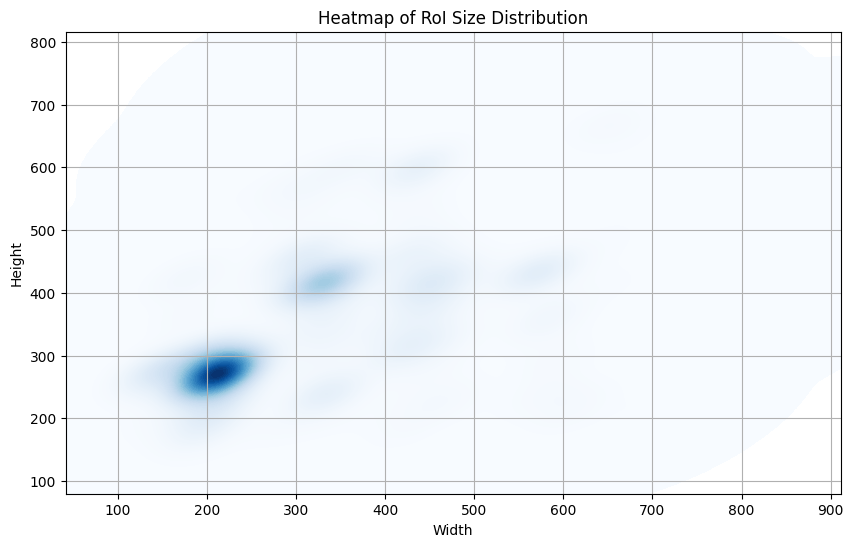

In [8]:
# Visualize RoI Distributions
visualize_roi_distributions(model, test_folder, transforms, device)

The Region of Interest (RoI) size distribution reveals that the chocolates in the dataset are generally of a specific size range. This consistency in size is helpful when choosing the anchor sizes and aspect ratios for the Region Proposal Network (RPN) in the Faster R-CNN model. By aligning the anchor sizes with the chocolate sizes, we can improve the model's ability to detect and classify chocolates accurately.

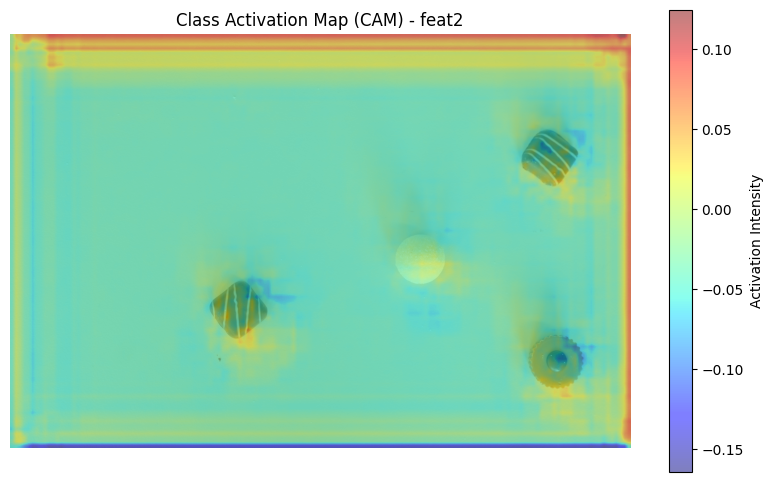

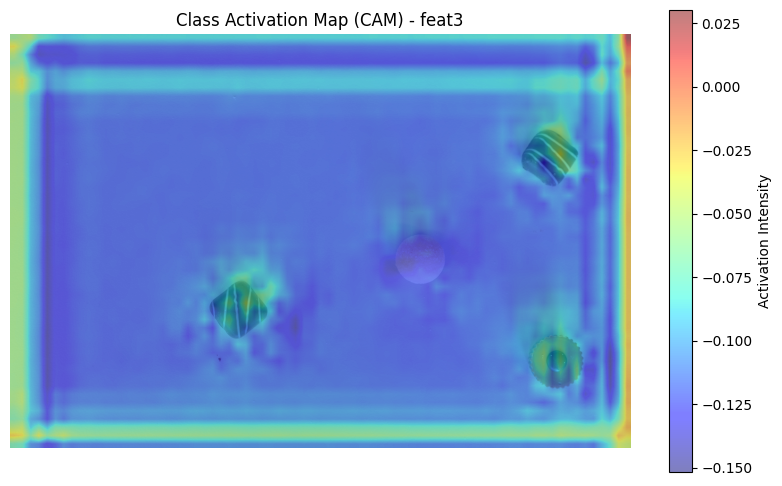

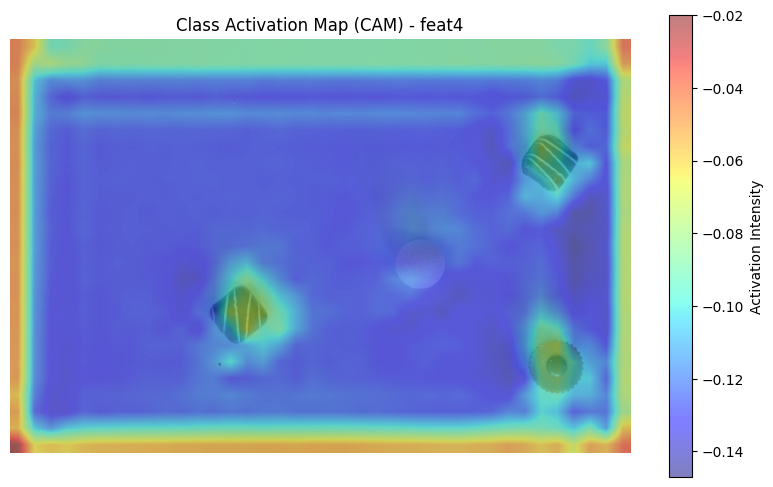

In [16]:
visualize_cams(model, test_folder, transforms, device)

The Class activation map (CAM), shows us that the regions containing chocolate are the most important even when only inspecting the backbone of the model (in our case it was ResNet-18). This indicates that the model is effectively learning to focus on the relevant features of the chocolates, which is a positive sign for its performance. The CAM highlights the areas of the image that contribute most to the model's predictions, allowing us to visualize what the model is "looking at" when making decisions. This can help us understand how well the model is learning to identify chocolates based on their visual characteristics.

# Grad-CAM Visualization

Grad-CAM (Gradient-weighted Class Activation Mapping) is a technique to visualize the regions of an image that contribute most to the model's predictions. By computing the gradients of the target class with respect to the feature maps, we can generate a heatmap that highlights the important areas.

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def grad_cam(model, img_tensor, target_layer, device='cpu'):
    """
    Generate Grad-CAM for a specific layer.

    Args:
        model: The trained model.
        img_tensor: The input image tensor.
        target_layer: The layer to compute Grad-CAM for.
        device: The device to run the computation on.

    Returns:
        A heatmap of the Grad-CAM.
    """
    model.eval()

    # Forward pass
    img_tensor = img_tensor.unsqueeze(0).to(device)
    features = []
    gradients = []

    def forward_hook(module, input, output):
        features.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    handle_forward = target_layer.register_forward_hook(forward_hook)
    handle_backward = target_layer.register_backward_hook(backward_hook)

    output = model(img_tensor)
    target_class = output[0]['scores'].argmax().item()

    # Backward pass
    model.zero_grad()
    output[0]['scores'][target_class].backward()

    # Compute Grad-CAM
    grad = gradients[0].cpu().data.numpy()
    fmap = features[0].cpu().data.numpy()
    weights = np.mean(grad, axis=(2, 3))
    cam = np.sum(weights[:, :, None, None] * fmap, axis=1).squeeze()

    # Normalize CAM
    cam = np.maximum(cam, 0)
    cam = (cam - cam.min()) / (cam.max() - cam.min())

    handle_forward.remove()
    handle_backward.remove()

    return cam

# Saliency Map Visualization

Saliency maps highlight the pixels in the input image that have the highest impact on the model's predictions. This is achieved by computing the gradient of the output with respect to the input image.

In [11]:
def saliency_map(model, img_tensor, device='cpu'):
    """
    Generate a saliency map for the input image.

    Args:
        model: The trained model.
        img_tensor: The input image tensor.
        device: The device to run the computation on.

    Returns:
        A saliency map highlighting important pixels.
    """
    model.eval()

    img_tensor = img_tensor.unsqueeze(0).to(device)
    img_tensor.requires_grad_()

    # Forward pass
    output = model(img_tensor)
    target_class = output[0]['scores'].argmax().item()

    # Backward pass
    model.zero_grad()
    output[0]['scores'][target_class].backward()

    # Compute saliency
    saliency = img_tensor.grad.abs().squeeze().cpu().numpy()
    saliency = np.max(saliency, axis=0)  # Take the maximum across channels

    return saliency

# Metrics Evaluation on the Train Set

To demonstrate that the model is learning effectively, we evaluate its performance on the training set using metrics such as precision, recall, and F1-score. These metrics provide insights into the model's ability to detect and classify chocolates accurately.

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_metrics(model, dataset, device='cpu'):
    """
    Evaluate precision, recall, and F1-score on the training set.

    Args:
        model: The trained model.
        dataset: The training dataset.
        device: The device to run the computation on.

    Returns:
        Precision, recall, and F1-score.
    """
    model.eval()
    all_preds = []
    all_targets = []

    for img, target in dataset:
        img = img.to(device)
        target_labels = target['labels'].cpu().numpy()

        with torch.no_grad():
            preds = model([img])[0]
            pred_labels = preds['labels'].cpu().numpy()

        all_preds.extend(pred_labels)
        all_targets.extend(target_labels)

    precision = precision_score(all_targets, all_preds, average='weighted')
    recall = recall_score(all_targets, all_preds, average='weighted')
    f1 = f1_score(all_targets, all_preds, average='weighted')

    return precision, recall, f1

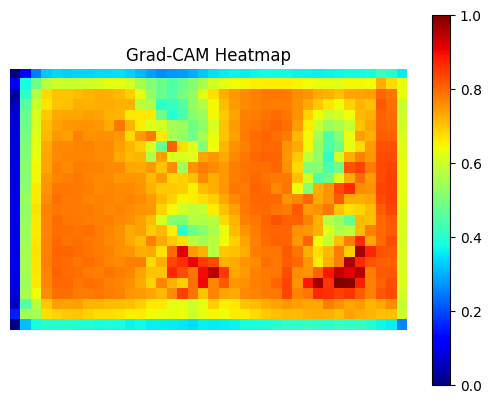

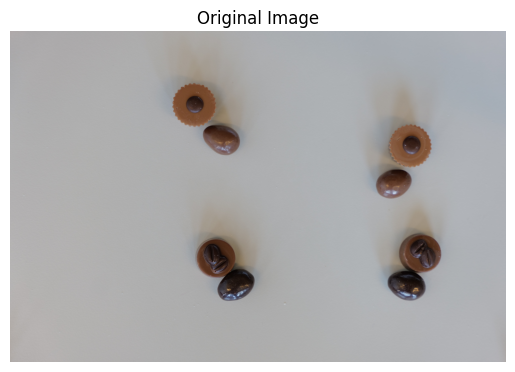

In [27]:
# Test Grad-CAM
# Example usage of Grad-CAM
# Ensure that the model and target_layer are properly defined
# Example:
target_layer = model.backbone[0]["layer4"]  # Adjust based on your model's architecture
img_tensor, _ = transforms(Image.open("dataset_project_iapr2025/test/L1000799.JPG"), {})
cam = grad_cam(model, img_tensor, target_layer, device)
plt.imshow(cam, cmap='jet')
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()

# Plot the original images
img = Image.open("dataset_project_iapr2025/test/L1000799.JPG")
plt.imshow(img)
plt.axis("off")
plt.title("Original Image")
plt.show()

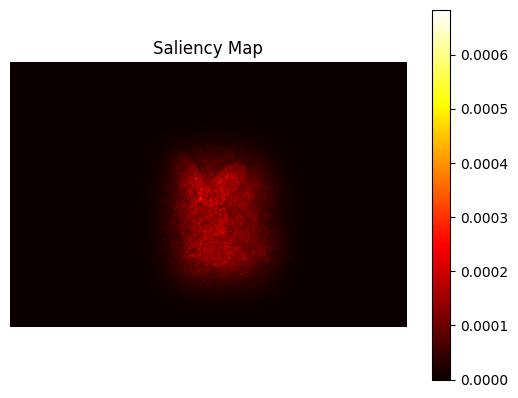

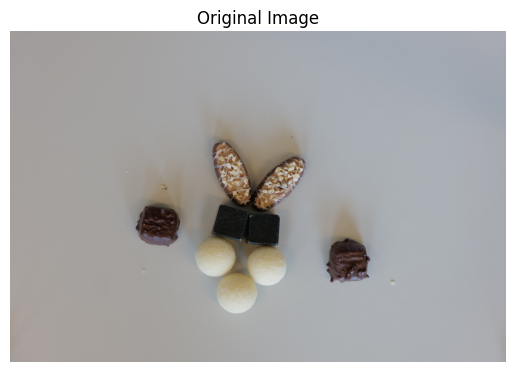

In [32]:
# Test Saliency Map
# Example usage of Saliency Map
# Ensure that the model and img_tensor are properly defined
# Example:
img_tensor, _ = transforms(Image.open("dataset_project_iapr2025/test/L1000812.JPG"), {})
saliency = saliency_map(model, img_tensor, device)
plt.imshow(saliency, cmap='hot')
plt.colorbar()
plt.title("Saliency Map")
plt.axis("off")
plt.show()

# Plot the original image
img = Image.open("dataset_project_iapr2025/test/L1000812.JPG")
plt.imshow(img)
plt.axis("off")
plt.title("Original Image")
plt.show()

In [ ]:
## PUT METRICS HERE